# Assignment 2: Evaluating the Impact of FOMC Communications on Asset Prices

FRE-GY 7871 A · NLP and the Investment Process · Fall 2026 · Yuri Moghaddam Nasrollahi (ym3414)

This notebook runs on the cached corpus, tone scores and market panel produced by `scripts/01–03`
(none of which are committed). It produces every exhibit in the report, in the order of the assignment sheet:
Table 1 (documents), Figure 1 (tone over time), Table 2 (Warsh-era releases and market changes),
Table 3 (regressions with the 3-month bill control), and the inputs to the forecast.

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from src import config as C
from src.collect import load_corpus
from src.lexicon import n_patterns, HAWKISH, DOVISH
from src.market import load_panel, attach_market, CHANGE_COLS, CHANGE_LABELS
from src.regress import add_tone_changes, run_table, format_table, stars
from src import exhibits as X
pd.set_option('display.width', 160, 'display.max_columns', 30, 'display.max_colwidth', 50)

corpus = load_corpus()
scores = pd.read_csv(C.INTERIM / 'scores.csv', parse_dates=['date'])
panel = load_panel()
print(len(corpus), 'documents;', scores.shape, 'score rows; panel', panel.index.min().date(), '→', panel.index.max().date())

308 documents; (308, 28) score rows; panel 2017-12-01 → 2026-09-11


## 1. The corpus (Table 1)

In [2]:
t1 = X.table1(corpus)
t1

,Document,Powell,Warsh,Total,Median words
0,Statement,68,2,70,351
1,Minutes,64,2,66,7964
2,Press conference,64,2,66,6550
3,Speech,78,1,79,1286
4,Testimony,26,1,27,1274
5,All documents,300,8,308,2749


In [3]:
# Warsh's post-meeting statements are much shorter than Powell's
corpus[corpus.subtype == 'statement'].groupby('chair').n_words.describe()[['count', 'mean', 'min', 'max']]

,count,mean,min,max
chair,,,,
Powell,68.0,382.779412,127.0,690.0
Warsh,2.0,152.000000,134.0,170.0


## 2. Tone scores

Three scores per document:

* **Word list** (`lex_net`): 56 hawkish and 55 dovish phrase patterns built for monetary-policy language,
  in four themes (inflation, activity, labor, policy) with negation handling. Score = (H − D)/(H + D) ∈ [−1, 1].
* **FinBERT sentiment** (`fb_sent`): mean over sentences of P(positive) − P(negative) from `ProsusAI/finbert`.
* **FinBERT similarity** (`fb_sim`): mean over sentences of cos(sentence, hawkish anchors) − cos(sentence, dovish anchors),
  where the anchors are key sentences such as *"Interest rates will rise"* / *"Interest rates will fall"*.

In [4]:
print(n_patterns())
print('Hawkish policy phrases, e.g.:', HAWKISH['policy'][:4])
print('Dovish inflation phrases, e.g.:', DOVISH['inflation'][:3])

{'hawkish': 56, 'dovish': 55}
Hawkish policy phrases, e.g.: ['rais(?:e|ed|ing) (?:the )?(?:target range|interest rates?|the federal funds rate|rates?|policy rate)', 'increas(?:e|ed|ing) (?:in )?(?:the )?target range', 'rate (?:hikes?|increases?)', 'hik(?:e|es|ed|ing)']
Dovish inflation phrases, e.g.: ['lower inflation', 'inflation (?:has |have )?(?:eased|declined|moderated|slowed|come down|fallen|receded|diminished|cooled|softened|subsided)', 'inflation (?:remains?|is|stays?) (?:low|subdued|muted|contained|below|soft)']


In [5]:
scores[C.TONE_SCORES + ['n_sent']].describe().round(3)

,lex_net,fb_sent,fb_sim,n_sent
count,308.000,308.000,308.000,308.000
mean,0.027,0.060,0.005,176.023
std,0.536,0.116,0.012,147.939
min,-1.000,-0.227,-0.031,7.000
25%,-0.333,-0.007,-0.003,25.500
50%,0.000,0.046,0.005,123.500
75%,0.400,0.113,0.011,319.000
max,1.000,0.547,0.053,500.000


In [6]:
# correlation between the three measures, by document type
for dt in ['statement', 'minutes', 'speech']:
    print(dt); print(scores[scores.doc_type == dt][C.TONE_SCORES].corr().round(2)); print()

statement
         lex_net  fb_sent  fb_sim
lex_net     1.00    -0.12   -0.03
fb_sent    -0.12     1.00    0.89
fb_sim     -0.03     0.89    1.00

minutes
         lex_net  fb_sent  fb_sim
lex_net     1.00     0.15    0.21
fb_sent     0.15     1.00    0.89
fb_sim      0.21     0.89    1.00

speech
         lex_net  fb_sent  fb_sim
lex_net     1.00    -0.09   -0.02
fb_sent    -0.09     1.00    0.91
fb_sim     -0.02     0.91    1.00



### Figure 1. Tone over time by document type

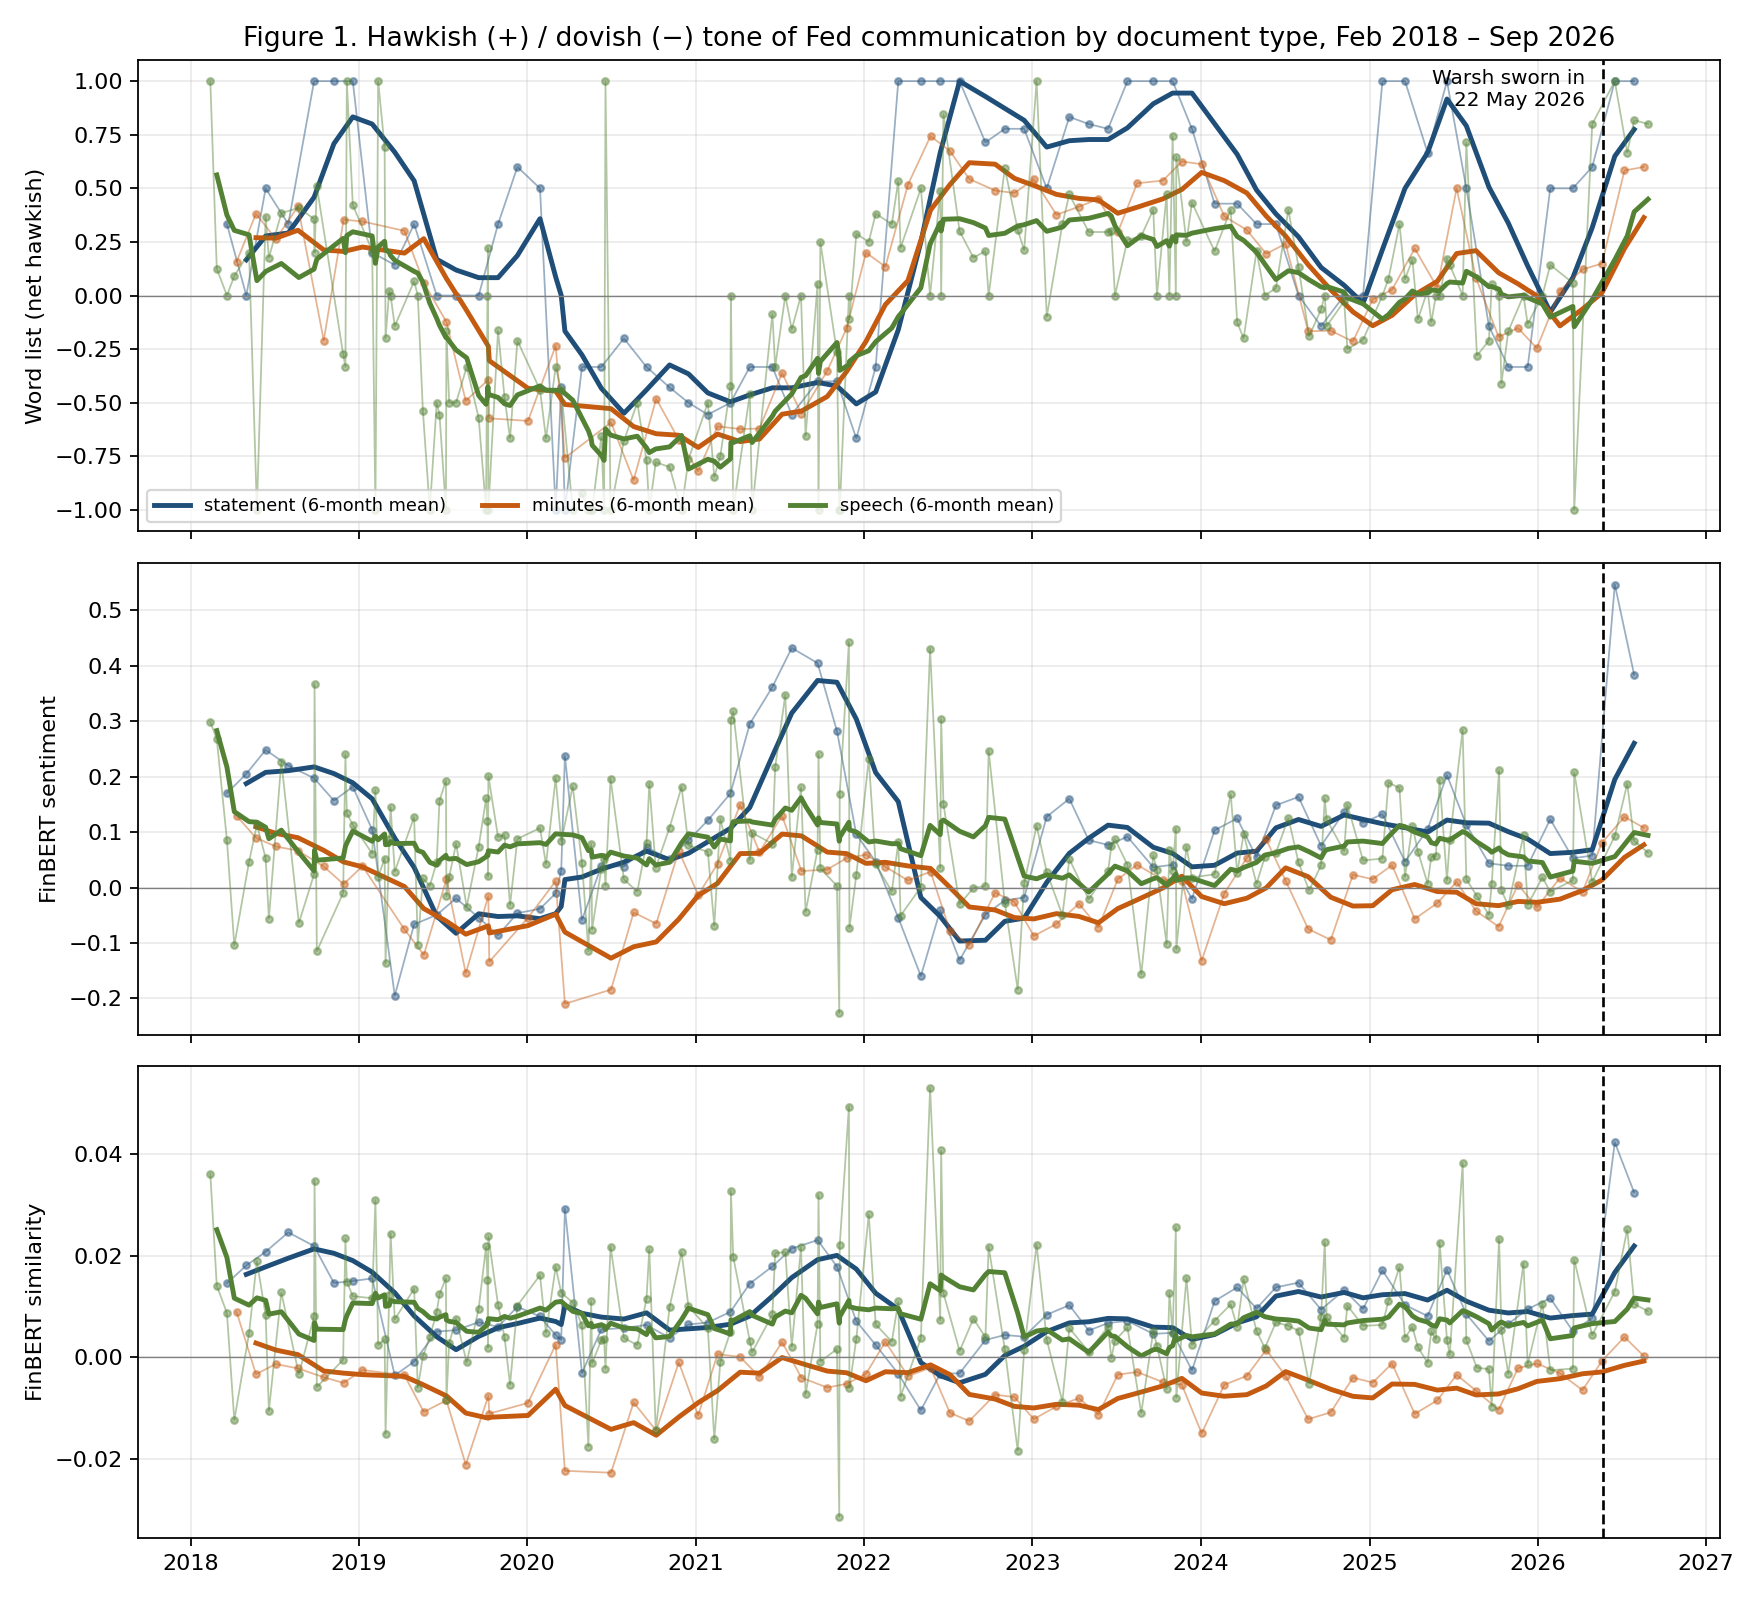

In [7]:
path = X.figure1(scores)
display(Image(path))

### Powell vs Warsh

In [8]:
by_chair = X.summary_by_chair(scores)
by_chair.round(3)

lex_net              fb_sent              fb_sim             
                    mean    std count    mean    std count   mean    std count
doc_type  chair                                                               
minutes   Powell   0.023  0.434    64  -0.008  0.074    64 -0.006  0.006    64
          Warsh    0.592  0.012     2   0.118  0.014     2  0.002  0.003     2
speech    Powell  -0.098  0.509   168   0.070  0.110   168  0.008  0.012   168
          Warsh    0.821  0.137     4   0.107  0.055     4  0.014  0.007     4
statement Powell   0.249  0.573    68   0.083  0.123    68  0.009  0.007    68
          Warsh    1.000  0.000     2   0.465  0.115     2  0.037  0.007     2

In [9]:
# Welch t-tests / rank tests: is the Warsh-era mean different from Powell's, by document type?
from scipy import stats
rows = []
for dt in ['statement', 'minutes', 'speech']:
    for s in C.TONE_SCORES:
        p = scores[(scores.doc_type == dt) & (scores.chair == 'Powell')][s].dropna()
        w = scores[(scores.doc_type == dt) & (scores.chair == 'Warsh')][s].dropna()
        pct = (p < w.mean()).mean()   # where Warsh's mean sits in Powell's distribution
        rows.append(dict(doc_type=dt, score=s, powell_mean=p.mean(), warsh_mean=w.mean(), n_w=len(w),
                         warsh_pctile_in_powell=pct, mwu_p=stats.mannwhitneyu(p, w).pvalue if len(w) > 1 else np.nan))
cmp = pd.DataFrame(rows); cmp.to_csv(C.OUTPUTS / 'powell_vs_warsh_tests.csv', index=False); cmp.round(3)

,doc_type,score,powell_mean,warsh_mean,n_w,warsh_pctile_in_powell,mwu_p
0,statement,lex_net,0.249,1.000,2,0.809,0.053
1,statement,fb_sent,0.083,0.465,2,1.000,0.003
2,statement,fb_sim,0.009,0.037,2,1.000,0.001
3,minutes,lex_net,0.023,0.592,2,0.938,0.023
4,minutes,fb_sent,-0.008,0.118,2,0.953,0.015
5,minutes,fb_sim,-0.006,0.002,2,0.938,0.019
6,speech,lex_net,-0.098,0.821,4,0.964,0.002
7,speech,fb_sent,0.070,0.107,4,0.702,0.239
8,speech,fb_sim,0.008,0.014,4,0.768,0.091


In [10]:
# The same comparison against Powell's last year only (Jun 2025 - May 2026), which is the fairer baseline
last = scores[(scores.chair == 'Powell') & (scores.date >= '2025-05-22')]
rows = []
for dt in ['statement', 'minutes', 'speech']:
    for s in C.TONE_SCORES:
        rows.append(dict(doc_type=dt, score=s, powell_last12m=last[last.doc_type == dt][s].mean(),
                         warsh=scores[(scores.doc_type == dt) & (scores.chair == 'Warsh')][s].mean()))
pd.DataFrame(rows).round(3)

,doc_type,score,powell_last12m,warsh
0,statement,lex_net,0.286,1.000
1,statement,fb_sent,0.084,0.465
2,statement,fb_sim,0.009,0.037
3,minutes,lex_net,0.036,0.592
4,minutes,fb_sent,-0.008,0.118
5,minutes,fb_sim,-0.005,0.002
6,speech,lex_net,-0.006,0.821
7,speech,fb_sent,0.056,0.107
8,speech,fb_sim,0.007,0.014


In [11]:
# Which themes drive the word-list score in statements, by Chair
theme_cols = [c for c in scores.columns if c.startswith(('hawk_', 'dove_'))]
scores[scores.subtype == 'statement'].groupby('chair')[theme_cols].mean().round(2).T

chair,Powell,Warsh
hawk_inflation,2.01,1.0
dove_inflation,0.51,0.0
hawk_activity,0.63,2.0
dove_activity,0.12,0.0
hawk_labor,0.15,0.0
dove_labor,0.19,0.0
hawk_policy,1.13,1.5
dove_policy,1.59,0.0


## 3. Market reactions

Day 0 is the release day if the release is before 16:00 ET on a trading day, else the next trading day.
Changes are close-to-close: percent for DXY, basis points for 10s2s and the 1-year yield, IWF return minus IWN
return in percent for growth-minus-value. The control is the same-day change in the 3-month bill (DGS3MO), in bp.

In [12]:
df = attach_market(scores, panel)
df = add_tone_changes(df)
print('releases with a usable day 0 and market data:', df[CHANGE_COLS + ['dDGS3MO']].dropna().shape[0], 'of', len(df))
df[CHANGE_COLS + ['dDGS3MO']].describe().round(2)

releases with a usable day 0 and market data: 307 of 308


,dDXY,d10s2s,dDGS1,dGmV,dDGS3MO
count,308.00,307.00,307.00,308.00,307.00
mean,-0.06,-0.42,-0.51,0.10,-0.64
std,0.44,4.25,5.26,1.23,3.20
min,-1.32,-12.00,-22.00,-6.39,-18.00
25%,-0.39,-3.00,-2.00,-0.55,-1.50
50%,-0.06,0.00,0.00,0.14,0.00
75%,0.25,2.00,1.50,0.80,1.00
max,1.22,12.00,20.00,4.62,12.00


In [13]:
# release-day moves vs all other days: is anything happening on Fed days at all?
from src.market import one_day_changes
allch = one_day_changes(panel).loc['2018-02-05':]
fed_days = set(df.day0.dropna())
print('abs one-day change, mean: Fed release days vs other days')
pd.DataFrame({'release days': allch[allch.index.isin(fed_days)].abs().mean(),
              'other days': allch[~allch.index.isin(fed_days)].abs().mean()}).round(2)

abs one-day change, mean: Fed release days vs other days


,release days,other days
dDXY,0.35,0.31
d10s2s,3.00,2.70
dDGS1,3.04,2.59
dGmV,0.88,0.84
dDGS3MO,1.67,1.76


### Table 2. Warsh-era releases: tone scores next to the one-day change in the four indicators

In [14]:
t2 = X.table2(df)
t2

,Release,Document,Title,Word list,FinBERT sent.,FinBERT sim.,ΔDXY (%),Δ10s2s (bp),Δ1y (bp),ΔG−V (%),Δ3m bill (bp)
300,2026-06-17,Press conference,"Press conference, 17 June 2026",1.00,0.093,1.29,0.55,-9.0,14.0,-0.26,4.0
301,2026-06-17,Statement,FOMC statement,1.00,0.547,4.23,0.55,-9.0,14.0,-0.26,4.0
302,2026-07-08,Minutes,Minutes of the June 2026 meeting,0.58,0.128,0.40,-0.09,-1.0,0.0,1.51,1.0
303,2026-07-14,Testimony,Semiannual Monetary Policy Report to the Congres,0.67,0.187,2.52,-0.34,4.0,-10.0,1.43,-5.0
304,2026-07-29,Press conference,"Press conference, 29 July 2026",0.82,0.084,1.05,-0.57,10.0,-5.0,-0.97,-7.0
305,2026-07-29,Statement,FOMC statement,1.00,0.384,3.24,-0.57,10.0,-5.0,-0.97,-7.0
306,2026-08-19,Minutes,Minutes of the July 2026 meeting,0.60,0.108,0.02,-0.82,-6.0,1.0,-0.84,0.0
307,2026-08-28,Speech,In Our Time,0.80,0.063,0.90,0.54,-8.0,11.0,-0.21,6.0


### Table 3. Each indicator's one-day change regressed on each tone score, with the 3-month bill control

$\Delta y_i = a + b\,z(\text{tone}_i) + c\,\Delta \text{DGS3MO}_i + \text{type dummies} + e_i$, HC1 standard errors.
Cells show $b$ (t-statistic); a one-unit move in the regressor is one standard deviation of the tone score.
Stars: * p<0.10, ** p<0.05, *** p<0.01.

In [15]:
t3_level = run_table(df, '', type_dummies=True)
t3_level.to_csv(C.OUTPUTS / 'table3_level_pooled.csv', index=False)
print('Panel A. All releases (statements, minutes, speeches), tone level, N =', t3_level.n.min(), '–', t3_level.n.max())
format_table(t3_level, CHANGE_LABELS)

Panel A. All releases (statements, minutes, speeches), tone level, N = 307 – 307


,DXY (%),10s2s (bp),1y yield (bp),Growth − value (%)
Word list (net hawkish),-0.017 (-0.70),+0.039 (0.16),-0.171 (-0.71),+0.090 (1.08)
FinBERT sentiment,+0.039 (1.60),+0.048 (0.19),-0.097 (-0.35),-0.055 (-0.80)
FinBERT similarity,+0.036 (1.33),-0.122 (-0.43),-0.215 (-0.74),-0.004 (-0.05)


In [16]:
t3_stmt = run_table(df[df.doc_type == 'statement'], '', type_dummies=False)
t3_stmt.to_csv(C.OUTPUTS / 'table3_level_statements.csv', index=False)
print('Panel B. Post-meeting statements only, tone level, N =', t3_stmt.n.min(), '–', t3_stmt.n.max())
format_table(t3_stmt, CHANGE_LABELS)

Panel B. Post-meeting statements only, tone level, N = 70 – 70


,DXY (%),10s2s (bp),1y yield (bp),Growth − value (%)
Word list (net hawkish),-0.029 (-0.58),+0.290 (0.53),-0.675 (-1.13),+0.066 (0.45)
FinBERT sentiment,+0.069 (1.46),+0.284 (0.45),+0.894 (1.56),-0.218** (-2.45)
FinBERT similarity,+0.079* (1.67),-0.205 (-0.29),+1.296** (2.02),-0.110 (-0.92)


In [17]:
t3_chg = run_table(df, '_chg', type_dummies=True)
t3_chg.to_csv(C.OUTPUTS / 'table3_change_pooled.csv', index=False)
print('Panel C. All releases, change in tone since the previous document of the same type (surprise proxy)')
format_table(t3_chg, CHANGE_LABELS)

Panel C. All releases, change in tone since the previous document of the same type (surprise proxy)


,DXY (%),10s2s (bp),1y yield (bp),Growth − value (%)
Word list (net hawkish),+0.021 (0.96),-0.154 (-0.80),+0.435** (2.19),+0.169*** (3.04)
FinBERT sentiment,+0.028 (1.20),-0.197 (-0.86),-0.352 (-1.25),+0.035 (0.50)
FinBERT similarity,+0.029 (1.36),-0.167 (-0.76),-0.336 (-1.45),+0.075 (1.08)


In [18]:
t3_stmt_chg = run_table(df[df.doc_type == 'statement'], '_chg', type_dummies=False)
t3_stmt_chg.to_csv(C.OUTPUTS / 'table3_change_statements.csv', index=False)
print('Panel D. Statements only, change in tone')
format_table(t3_stmt_chg, CHANGE_LABELS)

Panel D. Statements only, change in tone


,DXY (%),10s2s (bp),1y yield (bp),Growth − value (%)
Word list (net hawkish),-0.061 (-1.16),-0.708 (-1.50),+0.765 (1.26),+0.041 (0.30)
FinBERT sentiment,+0.062 (1.43),-1.264*** (-3.12),+0.354 (0.46),+0.080 (0.56)
FinBERT similarity,+0.035 (0.76),-1.137*** (-2.59),+0.530 (0.70),+0.190 (1.24)


In [19]:
# the control on its own: how much of each indicator's release-day move the rate decision explains
import statsmodels.api as sm
rows = []
for y in CHANGE_COLS:
    sub = df[[y, 'dDGS3MO']].dropna()
    m = sm.OLS(sub[y], sm.add_constant(sub['dDGS3MO'])).fit(cov_type='HC1')
    rows.append(dict(indicator=CHANGE_LABELS[y], b_bill=m.params['dDGS3MO'], t=m.tvalues['dDGS3MO'], r2=m.rsquared, n=int(m.nobs)))
pd.DataFrame(rows).round(3)

,indicator,b_bill,t,r2,n
0,DXY (%),0.037,4.484,0.073,307
1,10s2s (bp),-0.430,-5.828,0.106,307
2,1y yield (bp),0.960,9.707,0.343,307
3,Growth − value (%),0.009,0.507,0.001,307


In [20]:
# full detail behind Table 3, Panel A
t3_level.round(3)

,indicator,tone,b_tone,se_tone,t_tone,p_tone,b_bill,t_bill,n,r2
0,dDXY,lex_net,-0.017,0.024,-0.699,0.485,0.037,4.532,307,0.087
1,dDXY,fb_sent,0.039,0.025,1.596,0.110,0.036,4.388,307,0.093
2,dDXY,fb_sim,0.036,0.027,1.327,0.184,0.037,4.453,307,0.090
3,d10s2s,lex_net,0.039,0.242,0.163,0.870,-0.438,-5.908,307,0.108
4,d10s2s,fb_sent,0.048,0.256,0.188,0.850,-0.439,-5.893,307,0.108
5,d10s2s,fb_sim,-0.122,0.281,-0.435,0.664,-0.437,-5.905,307,0.109
6,dDGS1,lex_net,-0.171,0.240,-0.712,0.476,0.960,9.706,307,0.347
7,dDGS1,fb_sent,-0.097,0.281,-0.348,0.728,0.960,9.903,307,0.346
8,dDGS1,fb_sim,-0.215,0.290,-0.742,0.458,0.958,9.747,307,0.347
9,dGmV,lex_net,0.090,0.084,1.075,0.282,0.010,0.528,307,0.016


## 4. Inputs to the forecast

The forecast in the report combines (i) where Warsh's tone sits relative to Powell's, (ii) the estimated
response of each indicator to tone and to the bill change, and (iii) the Warsh-era release-day record.

In [21]:
# 1. Warsh's statements relative to the Powell distribution
stm = scores[scores.subtype == 'statement'].sort_values('date')
for s in C.TONE_SCORES:
    p = stm[stm.chair == 'Powell'][s]
    print(f"{s:8s} Powell mean {p.mean():+.3f} sd {p.std():.3f} | Warsh Jun {stm.iloc[-2][s]:+.3f}  Jul {stm.iloc[-1][s]:+.3f}")
stm.tail(6)[['date', 'chair', 'n_words', 'hawk', 'dove'] + C.TONE_SCORES].round(3)

lex_net  Powell mean +0.249 sd 0.573 | Warsh Jun +1.000  Jul +1.000
fb_sent  Powell mean +0.083 sd 0.123 | Warsh Jun +0.547  Jul +0.384
fb_sim   Powell mean +0.009 sd 0.007 | Warsh Jun +0.042  Jul +0.032


,date,chair,n_words,hawk,dove,lex_net,fb_sent,fb_sim
287,2025-12-10,Powell,389,2,4,-0.333,0.039,0.009
291,2026-01-28,Powell,295,3,1,0.500,0.123,0.012
294,2026-03-18,Powell,309,3,1,0.500,0.053,0.005
298,2026-04-29,Powell,344,4,1,0.600,0.058,0.008
301,2026-06-17,Warsh,134,4,0,1.000,0.547,0.042
305,2026-07-29,Warsh,170,5,0,1.000,0.384,0.032


In [22]:
# 2. Statement-to-statement tone: how often is a statement more hawkish than the previous one, and after a hawkish one?
for s in C.TONE_SCORES:
    d = stm[s].diff()
    up = (d > 0).mean()
    # conditional on the previous statement being in the top quartile of hawkishness
    hi = stm[s].shift(1) > stm[s].quantile(0.75)
    print(f"{s:8s} P(more hawkish than previous) = {up:.2f}; when previous was top-quartile hawkish = {(d[hi] > 0).mean():.2f}  (n={hi.sum()})")

lex_net  P(more hawkish than previous) = 0.31; when previous was top-quartile hawkish = 0.00  (n=16)
fb_sent  P(more hawkish than previous) = 0.54; when previous was top-quartile hawkish = 0.29  (n=17)
fb_sim   P(more hawkish than previous) = 0.60; when previous was top-quartile hawkish = 0.41  (n=17)


In [23]:
# 3. Release-day direction: how often does each indicator rise on a statement day, overall and on hawkish-statement days
st = df[df.doc_type == 'statement'].dropna(subset=CHANGE_COLS)
hawk = st.lex_net > st.lex_net.median()
pd.DataFrame({'P(rise) all statement days': (st[CHANGE_COLS] > 0).mean(),
              'P(rise) | hawkish statement': (st.loc[hawk, CHANGE_COLS] > 0).mean(),
              'P(rise) | bill up on the day': (st.loc[st.dDGS3MO > 0, CHANGE_COLS] > 0).mean(),
              'mean change | hawkish': st.loc[hawk, CHANGE_COLS].mean(),
              'mean |change| all': st[CHANGE_COLS].abs().mean()}).round(2)

,P(rise) all statement days,P(rise) | hawkish statement,P(rise) | bill up on the day,mean change | hawkish,mean |change| all
dDXY,0.37,0.39,0.50,-0.12,0.40
d10s2s,0.43,0.33,0.22,-0.55,3.61
dDGS1,0.33,0.39,0.44,-1.64,3.90
dGmV,0.53,0.61,0.67,0.18,0.94


In [24]:
# 4. The market's own pricing going into 16 September: 3-month bill vs the middle of the target range
last = panel.dropna(subset=['DGS3MO']).iloc[-1]
print('as of', panel.dropna(subset=['DGS3MO']).index[-1].date(), 'DGS3MO =', last.DGS3MO, ' DGS1 =', last.DGS1, ' 10s2s =', last.T10Y2Y, ' DXY =', round(last.DXY, 2))
print('target range 3.50-3.75; a 3m bill at', last.DGS3MO, 'sits', round((last.DGS3MO - 3.625) * 100), 'bp above the midpoint')

as of 2026-09-10 DGS3MO = 4.0  DGS1 = 4.28  10s2s = 0.39  DXY = 99.09
target range 3.50-3.75; a 3m bill at 4.0 sits 38 bp above the midpoint


In [25]:
# 5. Warsh-era release days, all together
df[df.chair == 'Warsh'][['date', 'subtype'] + C.TONE_SCORES + CHANGE_COLS + ['dDGS3MO']].round(3)

,date,subtype,lex_net,fb_sent,fb_sim,dDXY,d10s2s,dDGS1,dGmV,dDGS3MO
300,2026-06-17,press_conference,1.000,0.093,0.013,0.553,-9.0,14.0,-0.258,4.0
301,2026-06-17,statement,1.000,0.547,0.042,0.553,-9.0,14.0,-0.258,4.0
302,2026-07-08,minutes,0.583,0.128,0.004,-0.089,-1.0,0.0,1.506,1.0
303,2026-07-14,testimony,0.667,0.187,0.025,-0.336,4.0,-10.0,1.431,-5.0
304,2026-07-29,press_conference,0.818,0.084,0.011,-0.572,10.0,-5.0,-0.966,-7.0
305,2026-07-29,statement,1.000,0.384,0.032,-0.572,10.0,-5.0,-0.966,-7.0
306,2026-08-19,minutes,0.600,0.108,0.000,-0.823,-6.0,1.0,-0.842,0.0
307,2026-08-28,speech,0.800,0.063,0.009,0.545,-8.0,11.0,-0.208,6.0
